# Progression‑First Deep Learning Pipeline (Melbourne)

This notebook implements two small‑scale DL models for longitudinal progression:
1) **Multimodal fusion MLP** (predict FARS/SARA + progression score)
2) **Longitudinal pair model** (encode visit1/visit2, learn progression score)

Subject‑level LOO is used throughout. Metrics include Cohen’s d, SRM, paired t‑test, mean/SD change, and clinical prediction (R²/RMSE).


In [1]:
# Purpose: imports, config, paths
import os, warnings, copy, time
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import ttest_rel

warnings.filterwarnings('ignore')

BUNDLE_ROOT = Path('..').resolve()
os.chdir(BUNDLE_ROOT)
print('Working directory:', Path.cwd())

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cpu')

DATA_PATH = Path('data/processed/melbourne_frda_merged.csv')

# Runtime control
RUN_MODE = 'dev'   # 'dev' or 'full'
RUN_BOOTSTRAP = False

if RUN_MODE == 'dev':
    EPOCHS = 20
    PATIENCE = 4
    N_BOOT = 20
    ACTIVE_COMBOS = None  # run all combinations  # run all combinations
else:
    EPOCHS = 20
    PATIENCE = 4
    N_BOOT = 20
    ACTIVE_COMBOS = None  # run all combinations

LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.2
VAL_FRACTION = 0.2
USE_CLINICAL_HEADS = True  # train progression head only by default

# Loss weights
LAMBDA_FARS = 1.0
LAMBDA_SARA = 1.0
LAMBDA_PROG = 1.0



Working directory: /Users/robertwang/Documents/New_project/baseline_composite_biomakers


In [2]:
# Purpose: load wide data and detect subject/clinical columns
melb_wide = pd.read_csv(DATA_PATH)

for _c in ['melb_id', 'ID', 'subject', 'subject_id']:
    if _c in melb_wide.columns:
        subject_col = _c
        break
else:
    raise KeyError('No subject id column found')

print('Subjects:', melb_wide[subject_col].nunique())
print('Columns:', len(melb_wide.columns))

# FARS/SARA columns
fars_v1_col = 'FARS1' if 'FARS1' in melb_wide.columns else None
fars_v2_col = 'FARS2' if 'FARS2' in melb_wide.columns else None
sara_v1_col = 'SARA1' if 'SARA1' in melb_wide.columns else None
sara_v2_col = 'SARA2' if 'SARA2' in melb_wide.columns else None

print('FARS cols:', fars_v1_col, fars_v2_col)
print('SARA cols:', sara_v1_col, sara_v2_col)


Subjects: 26
Columns: 69
FARS cols: FARS1 FARS2
SARA cols: SARA1 SARA2


In [3]:
# Purpose: feature groups, combinations, and modality cache
background = [
    'age',
    'age_at_onset',
    'dur',
    'sex',
    'GAA1',
    'GAA2',
]

structural = [
    'SCP', 'MCP', 'ICP',
    'Midbrain', 'Pons', 'Medulla',
    'AntCBLM', 'SupPostCBLM', 'InfPostCBLM', 'FlocCBLM', 'VermisCBLM'
]

structural_ext = structural + ['CSA_C1', 'CSA_C2', 'ECC_C1', 'ECC_C2']

diffusion = [
    'FASCP', 'FAMCP', 'FAICP',
    'MDSCP', 'MDMCP', 'MDICP',
    'ADSCP', 'ADMCP', 'ADICP',
    'RDSCP', 'RDMCP', 'RDICP'
]

all_combinations = [
    {'name': 'background', 'features': background},
    {'name': 'structural', 'features': structural},
    {'name': 'diffusion', 'features': diffusion},
    {'name': 'background_diffusion', 'features': background + diffusion},
    {'name': 'background_structural', 'features': background + structural},
    {'name': 'background_structural_ext', 'features': background + structural_ext},
    {'name': 'background_structural_diffusion', 'features': background + structural + diffusion},
    {'name': 'background_structural_ext_diffusion', 'features': background + structural_ext + diffusion}
]

if ACTIVE_COMBOS is None:
    combinations = all_combinations
else:
    combinations = [c for c in all_combinations if c['name'] in ACTIVE_COMBOS]

combo_meta = {}
for combo in combinations:
    feats = combo['features']
    combo_meta[combo['name']] = {
        'features': feats,
        'struct_idx': [i for i, f in enumerate(feats) if f in structural_ext],
        'diff_idx': [i for i, f in enumerate(feats) if f in diffusion],
        'back_idx': [i for i, f in enumerate(feats) if f in background],
    }

print('Combinations:', [c['name'] for c in combinations])


Combinations: ['background', 'structural', 'diffusion', 'background_diffusion', 'background_structural', 'background_structural_ext', 'background_structural_diffusion', 'background_structural_ext_diffusion']


In [4]:
# Purpose: build long format (visit=1/2)

def build_long_from_wide(df, subject_col):
    rows = []
    for _, r in df.iterrows():
        sid = r[subject_col]

        # visit 1
        row1 = {subject_col: sid, 'visit': 1}
        row1['age'] = r.get('age1')
        row1['age_at_onset'] = r.get('age_at_onset')
        row1['dur'] = r.get('dur1')
        row1['sex'] = r.get('sex')
        row1['GAA1'] = r.get('GAA1')
        row1['GAA2'] = r.get('GAA2')
        row1['FARS'] = r.get(fars_v1_col)
        row1['SARA'] = r.get(sara_v1_col)

        for f in structural_ext + diffusion:
            col = f + '_v1'
            if col in df.columns:
                row1[f] = r.get(col)

        # visit 2
        row2 = {subject_col: sid, 'visit': 2}
        row2['age'] = r.get('age2')
        row2['age_at_onset'] = r.get('age_at_onset')
        row2['dur'] = r.get('dur2')
        row2['sex'] = r.get('sex')
        row2['GAA1'] = r.get('GAA1')
        row2['GAA2'] = r.get('GAA2')
        row2['FARS'] = r.get(fars_v2_col)
        row2['SARA'] = r.get(sara_v2_col)

        for f in structural_ext + diffusion:
            col = f + '_v2'
            if col in df.columns:
                row2[f] = r.get(col)

        rows.append(row1)
        rows.append(row2)

    return pd.DataFrame(rows)

long_df = build_long_from_wide(melb_wide, subject_col)
print('Long rows:', len(long_df), 'subjects:', long_df[subject_col].nunique())


Long rows: 52 subjects: 26


In [5]:
# dataset helpers, paired metrics, and subject-based validation split

def filter_complete_pairs(df, subject_col, feature_cols):
    sub = df[[subject_col, 'visit'] + feature_cols + ['FARS','SARA']].copy()
    sub = sub.dropna(subset=feature_cols)
    counts = sub.groupby(subject_col)['visit'].nunique()
    valid = counts[counts == 2].index
    return sub[sub[subject_col].isin(valid)].copy()


def compute_paired_d(oof_df, subject_col, visit_col='visit', score_col='score'):
    paired = (oof_df.sort_values([subject_col, visit_col])
                .groupby(subject_col)[score_col]
                .apply(list))
    paired = paired[paired.map(len) == 2]
    if len(paired) < 2:
        return np.nan, np.nan, np.nan, 0
    diffs = paired.map(lambda x: x[1] - x[0]).astype(float)
    sd = diffs.std(ddof=1)
    d = np.nan if sd == 0 else diffs.mean() / sd
    return d, diffs.mean(), sd, len(diffs)


def compute_srm(oof_df, subject_col, visit_col='visit', score_col='score'):
    d, _, _, _ = compute_paired_d(oof_df, subject_col, visit_col, score_col)
    return d


def paired_ttest(oof_df, subject_col, visit_col='visit', score_col='score'):
    paired = (oof_df.sort_values([subject_col, visit_col])
                .groupby(subject_col)[score_col]
                .apply(list))
    paired = paired[paired.map(len) == 2]
    if len(paired) < 2:
        return np.nan
    v1 = paired.map(lambda x: x[0]).astype(float)
    v2 = paired.map(lambda x: x[1]).astype(float)
    return ttest_rel(v2, v1).pvalue


def bootstrap_subjects(df, subject_col, n_boot):
    subjects = df[subject_col].unique()
    rng = np.random.RandomState(RANDOM_SEED)
    for _ in range(n_boot):
        samp = rng.choice(subjects, size=len(subjects), replace=True)
        yield df[df[subject_col].isin(samp)].copy()


def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)


def split_train_val_subjects(train_df, subject_col, val_fraction=VAL_FRACTION):
    subjects = np.array(sorted(train_df[subject_col].unique()))
    rng = np.random.RandomState(RANDOM_SEED)
    rng.shuffle(subjects)
    n_val = max(1, int(round(len(subjects) * val_fraction)))
    val_subjects = set(subjects[:n_val])
    train_subjects = set(subjects[n_val:])
    if len(train_subjects) == 0:
        train_subjects = val_subjects
        val_subjects = set(subjects[:1])
    train_split = train_df[train_df[subject_col].isin(train_subjects)].copy()
    val_split = train_df[train_df[subject_col].isin(val_subjects)].copy()
    return train_split, val_split


def make_paired_progression_targets(df, subject_col, value_col='visit'):
    paired = []
    for sid, g in df.groupby(subject_col):
        g = g.sort_values('visit')
        if g['visit'].nunique() != 2:
            continue
        paired.append((sid, g))
    return paired


In [6]:
# model definitions

class MLPEncoder(nn.Module):
    def __init__(self, in_dim, hidden=8, out_dim=4, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim), nn.ReLU(), nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)


class FusionModel(nn.Module):
    def __init__(self, dims, dropout=0.3):
        super().__init__()
        self.enc_struct = MLPEncoder(dims['struct'], hidden=8, out_dim=4, dropout=dropout)
        self.enc_diff = MLPEncoder(dims['diff'], hidden=8, out_dim=4, dropout=dropout)
        self.enc_back = MLPEncoder(dims['back'], hidden=4, out_dim=2, dropout=dropout)

        fused_dim = 4 + 4 + 2
        self.head = nn.Sequential(
            nn.Linear(fused_dim, 4), nn.ReLU(), nn.Dropout(dropout)
        )
        self.fars = nn.Linear(4, 1)
        self.sara = nn.Linear(4, 1)
        self.prog = nn.Linear(4, 1)

    def forward(self, x_struct, x_diff, x_back):
        h = torch.cat([
            self.enc_struct(x_struct),
            self.enc_diff(x_diff),
            self.enc_back(x_back)
        ], dim=1)
        h = self.head(h)
        fars = self.fars(h)
        sara = self.sara(h)
        prog = self.prog(h)
        return fars, sara, prog


class PairModel(nn.Module):
    def __init__(self, in_dim, dropout=0.3):
        super().__init__()
        self.enc = MLPEncoder(in_dim, hidden=8, out_dim=4, dropout=dropout)
        self.prog = nn.Linear(4, 1)
        self.fars = nn.Linear(4, 1)
        self.sara = nn.Linear(4, 1)

    def forward(self, x1, x2):
        z1 = self.enc(x1)
        z2 = self.enc(x2)
        dz = z2 - z1
        prog = self.prog(dz)
        fars1 = self.fars(z1)
        fars2 = self.fars(z2)
        sara1 = self.sara(z1)
        sara2 = self.sara(z2)
        return prog, fars1, fars2, sara1, sara2


In [7]:
# Purpose: training utilities with validation-based early stopping

def paired_progression_loss(scores, visits, subjects):
    """Differentiable paired progression loss.

    scores: torch.Tensor shape (n,) or (n,)
    visits: numpy array length n with values 1/2
    subjects: numpy array length n with subject ids

    Returns negative SRM-like objective: -mean(delta) / std(delta)
    where delta = score(V2) - score(V1) for each subject.
    """
    deltas = []
    # Python loop is fine for n~50; keeps computation in torch graph.
    for sid in np.unique(subjects):
        idx = np.where(subjects == sid)[0]
        if idx.size != 2:
            continue
        v = visits[idx]
        # Identify v1 and v2 positions
        try:
            i1 = idx[np.where(v == 1)[0][0]]
            i2 = idx[np.where(v == 2)[0][0]]
        except Exception:
            continue
        deltas.append(scores[i2] - scores[i1])

    if len(deltas) < 2:
        # Return 0 loss but keep it connected to graph if possible
        return scores.sum() * 0.0

    d = torch.stack(deltas)
    return -(d.mean() / (d.std(unbiased=True) + 1e-6))



def prepare_fusion_arrays(df, feature_cols, meta, scaler):
    X = scaler.transform(df[feature_cols].values)
    arrays = {
        'struct': torch.tensor(X[:, meta['struct_idx']], dtype=torch.float32, device=DEVICE),
        'diff': torch.tensor(X[:, meta['diff_idx']], dtype=torch.float32, device=DEVICE),
        'back': torch.tensor(X[:, meta['back_idx']], dtype=torch.float32, device=DEVICE),
        'fars': torch.tensor(df['FARS'].values.reshape(-1, 1), dtype=torch.float32, device=DEVICE),
        'sara': torch.tensor(df['SARA'].values.reshape(-1, 1), dtype=torch.float32, device=DEVICE),
        'visit': np.array(df['visit'].values),
        'subject': np.array(df[subject_col].values),
    }
    return arrays


def evaluate_fusion_loss(model, arrays):
    fars, sara, prog = model(arrays['struct'], arrays['diff'], arrays['back'])
    if USE_CLINICAL_HEADS:
        loss_fars = F.mse_loss(fars, arrays['fars'])
        loss_sara = F.mse_loss(sara, arrays['sara'])
    else:
        loss_fars = torch.tensor(0.0, device=fars.device)
        loss_sara = torch.tensor(0.0, device=fars.device)
    loss_prog = paired_progression_loss(prog.view(-1), arrays['visit'], arrays['subject'])
    total_loss = LAMBDA_PROG * loss_prog + LAMBDA_FARS * loss_fars + LAMBDA_SARA * loss_sara
    return total_loss, fars, sara, prog


def train_fusion_model(train_df, feature_cols, meta, scaler):
    train_split, val_split = split_train_val_subjects(train_df, subject_col)
    train_arrays = prepare_fusion_arrays(train_split, feature_cols, meta, scaler)
    val_arrays = prepare_fusion_arrays(val_split, feature_cols, meta, scaler)

    dims = {
        'struct': len(meta['struct_idx']),
        'diff': len(meta['diff_idx']),
        'back': len(meta['back_idx']),
    }
    model = FusionModel(dims, dropout=DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val = np.inf
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    patience = 0

    for epoch in range(EPOCHS):
        model.train()
        opt.zero_grad()
        train_loss, _, _, _ = evaluate_fusion_loss(model, train_arrays)
        train_loss.backward()
        opt.step()

        model.eval()
        with torch.inference_mode():
            val_loss, _, _, _ = evaluate_fusion_loss(model, val_arrays)
        val_value = float(val_loss.item())

        if val_value < best_val:
            best_val = val_value
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            patience = 0
        else:
            patience += 1
        if patience >= PATIENCE:
            break

    model.load_state_dict(best_state)
    return model, best_epoch


def prepare_pair_arrays(df, feature_cols, scaler):
    x1_list, x2_list, sids = [], [], []
    for sid, g in df.groupby(subject_col):
        g = g.sort_values('visit')
        if g['visit'].nunique() != 2:
            continue
        x1 = g[g['visit'] == 1][feature_cols].values
        x2 = g[g['visit'] == 2][feature_cols].values
        if len(x1) == 1 and len(x2) == 1:
            x1_list.append(x1.ravel())
            x2_list.append(x2.ravel())
            sids.append(sid)
    X1 = torch.tensor(scaler.transform(np.vstack(x1_list)), dtype=torch.float32, device=DEVICE)
    X2 = torch.tensor(scaler.transform(np.vstack(x2_list)), dtype=torch.float32, device=DEVICE)
    F1 = np.array([df[df[subject_col]==sid].sort_values("visit")["FARS"].iloc[0] for sid in sids], dtype=float)
    F2 = np.array([df[df[subject_col]==sid].sort_values("visit")["FARS"].iloc[1] for sid in sids], dtype=float)
    S1 = np.array([df[df[subject_col]==sid].sort_values("visit")["SARA"].iloc[0] for sid in sids], dtype=float)
    S2 = np.array([df[df[subject_col]==sid].sort_values("visit")["SARA"].iloc[1] for sid in sids], dtype=float)
    F1 = torch.tensor(F1.reshape(-1,1), dtype=torch.float32, device=DEVICE)
    F2 = torch.tensor(F2.reshape(-1,1), dtype=torch.float32, device=DEVICE)
    S1 = torch.tensor(S1.reshape(-1,1), dtype=torch.float32, device=DEVICE)
    S2 = torch.tensor(S2.reshape(-1,1), dtype=torch.float32, device=DEVICE)
    return X1, X2, np.array(sids), F1, F2, S1, S2


def train_pair_model(train_df, feature_cols, scaler):
    train_split, val_split = split_train_val_subjects(train_df, subject_col)
    X1_train, X2_train, sid_train, F1_train, F2_train, S1_train, S2_train = prepare_pair_arrays(train_split, feature_cols, scaler)
    X1_val, X2_val, sid_val, F1_val, F2_val, S1_val, S2_val = prepare_pair_arrays(val_split, feature_cols, scaler)

    model = PairModel(X1_train.shape[1], dropout=DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val = np.inf
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    patience = 0

    for epoch in range(EPOCHS):
        model.train()
        opt.zero_grad()
        prog, _, _, _, _ = model(X1_train, X2_train)
        train_loss = -(prog.mean() / (prog.std(unbiased=True) + 1e-6))
        train_loss.backward()
        opt.step()

        model.eval()
        with torch.inference_mode():
            prog_val, fars1_v, fars2_v, sara1_v, sara2_v = model(X1_val, X2_val)
            prog_loss_v = -(prog_val.mean() / (prog_val.std(unbiased=True) + 1e-6))
            if USE_CLINICAL_HEADS:
                loss_fars_v = F.mse_loss(fars1_v, F1_val) + F.mse_loss(fars2_v, F2_val)
                loss_sara_v = F.mse_loss(sara1_v, S1_val) + F.mse_loss(sara2_v, S2_val)
            else:
                loss_fars_v = torch.tensor(0.0, device=DEVICE)
                loss_sara_v = torch.tensor(0.0, device=DEVICE)
            val_loss = LAMBDA_PROG * prog_loss_v + LAMBDA_FARS * loss_fars_v + LAMBDA_SARA * loss_sara_v
        val_value = float(val_loss.item())

        if val_value < best_val:
            best_val = val_value
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            patience = 0
        else:
            patience += 1
        if patience >= PATIENCE:
            break

    model.load_state_dict(best_state)
    return model, best_epoch


In [8]:
# Purpose: LOO evaluation (Fusion model) with cached modality structure and validation stopping
fusion_results = []
fusion_oof_all = []
fusion_weight_rows = []

for combo in combinations:
    feats = combo['features']
    meta = combo_meta[combo['name']]
    sub = filter_complete_pairs(long_df, subject_col, feats)
    subjects = sub[subject_col].unique()

    oof_rows = []
    fars_true, fars_pred = [], []
    sara_true, sara_pred = [], []
    epochs_used = []
    start_time = time.time()

    for sid in subjects:
        train = sub[sub[subject_col] != sid]
        test = sub[sub[subject_col] == sid]

        scaler = StandardScaler()
        scaler.fit(train[feats].values)

        model, best_epoch = train_fusion_model(train, feats, meta, scaler)
        epochs_used.append(best_epoch)
        model.eval()

        test_arrays = prepare_fusion_arrays(test, feats, meta, scaler)
        with torch.inference_mode():
            _, fars_out, sara_out, prog_out = evaluate_fusion_loss(model, test_arrays)

        prog_np = prog_out.detach().cpu().numpy().ravel()
        fars_np = fars_out.detach().cpu().numpy().ravel()
        sara_np = sara_out.detach().cpu().numpy().ravel()

        for v, sc in zip(test['visit'].values, prog_np):
            oof_rows.append({'subject': sid, 'visit': v, 'score': sc, 'method': 'FusionMLP', 'combination': combo['name']})

        fars_true.extend(test['FARS'].values)
        fars_pred.extend(fars_np)
        sara_true.extend(test['SARA'].values)
        sara_pred.extend(sara_np)

        # first-layer weight proxy for stability
        struct_w = model.enc_struct.net[0].weight.detach().cpu().numpy()
        diff_w = model.enc_diff.net[0].weight.detach().cpu().numpy()
        back_w = model.enc_back.net[0].weight.detach().cpu().numpy()
        for idx, f in enumerate([feats[i] for i in meta['struct_idx']]):
            fusion_weight_rows.append({'combination': combo['name'], 'feature': f, 'fold_subject': sid, 'weight': np.mean(np.abs(struct_w[:, idx]))})
        for idx, f in enumerate([feats[i] for i in meta['diff_idx']]):
            fusion_weight_rows.append({'combination': combo['name'], 'feature': f, 'fold_subject': sid, 'weight': np.mean(np.abs(diff_w[:, idx]))})
        for idx, f in enumerate([feats[i] for i in meta['back_idx']]):
            fusion_weight_rows.append({'combination': combo['name'], 'feature': f, 'fold_subject': sid, 'weight': np.mean(np.abs(back_w[:, idx]))})

    runtime = time.time() - start_time
    oof_df = pd.DataFrame(oof_rows)
    fusion_oof_all.append(oof_df)
    d, mean_diff, sd_diff, n = compute_paired_d(oof_df, 'subject')
    srm = compute_srm(oof_df, 'subject')
    p = paired_ttest(oof_df, 'subject')


    # Clinical metrics (only if heads trained; ignore missing labels)
    fars_r2 = np.nan
    fars_rmse = np.nan
    sara_r2 = np.nan
    sara_rmse = np.nan
    if USE_CLINICAL_HEADS:
        yft = np.asarray(fars_true, dtype=float)
        yfp = np.asarray(fars_pred, dtype=float)
        m = np.isfinite(yft) & np.isfinite(yfp)
        if m.sum() >= 3:
            fars_r2 = r2_score(yft[m], yfp[m])
            fars_rmse = rmse(yft[m], yfp[m])

        yst = np.asarray(sara_true, dtype=float)
        ysp = np.asarray(sara_pred, dtype=float)
        m = np.isfinite(yst) & np.isfinite(ysp)
        if m.sum() >= 3:
            sara_r2 = r2_score(yst[m], ysp[m])
            sara_rmse = rmse(yst[m], ysp[m])

    fusion_results.append({
        'model': 'FusionMLP',
        'combination': combo['name'],
        'd': d,
        'srm': srm,
        'mean_diff': mean_diff,
        'sd_diff': sd_diff,
        'p_value': p,
        'fars_r2': fars_r2,
        'fars_rmse': fars_rmse,
        'sara_r2': sara_r2,
        'sara_rmse': sara_rmse,
        'runtime_sec': runtime,
        'mean_epochs': float(np.mean(epochs_used)),
    })

fusion_results_df = pd.DataFrame(fusion_results)
fusion_results_df


,model,combination,d,srm,mean_diff,sd_diff,p_value,fars_r2,fars_rmse,sara_r2,sara_rmse,runtime_sec,mean_epochs
0,FusionMLP,background,-0.039819,-0.039819,-0.000099,0.002480,0.840750,-9.904040,86.664978,-5.805326,21.484451,0.967029,0.0
1,FusionMLP,structural,-0.107830,-0.107830,-0.000824,0.007637,0.587316,-9.904626,86.667304,-5.830459,21.524087,0.327707,0.0
2,FusionMLP,diffusion,-0.145945,-0.145945,-0.001446,0.009906,0.463708,-9.905207,86.669612,-5.757212,21.408369,0.320838,0.0
3,FusionMLP,background_diffusion,-0.001004,-0.001004,-0.000018,0.017486,0.995958,-9.918323,86.721719,-5.824006,21.513918,0.326520,0.0
4,FusionMLP,background_structural,0.401626,0.401626,0.002730,0.006797,0.051212,-9.878726,86.564321,-5.897591,21.629602,0.320588,0.0
5,FusionMLP,background_structural_ext,0.151635,0.151635,0.001461,0.009635,0.446659,-9.895132,86.629567,-5.839326,21.538054,0.351403,0.0
6,FusionMLP,background_structural_diffusion,-0.079241,-0.079241,-0.002240,0.028268,0.689611,-9.906312,86.674005,-5.820429,21.508278,0.339652,0.0
7,FusionMLP,background_structural_ext_diffusion,-0.116177,-0.116177,-0.002577,0.022182,0.558910,-9.904918,86.668463,-5.877135,21.597504,0.376471,0.0


In [9]:
# Purpose: Pair model evaluation (LOO) with validation stopping
pair_results = []
pair_oof_all = []
pair_weight_rows = []

for combo in combinations:
    feats = combo['features']
    sub = filter_complete_pairs(long_df, subject_col, feats)
    subjects = sub[subject_col].unique()

    oof_rows = []
    epochs_used = []
    fars_true, fars_pred = [], []
    sara_true, sara_pred = [], []
    start_time = time.time()

    for sid in subjects:
        train = sub[sub[subject_col] != sid]
        test = sub[sub[subject_col] == sid]

        scaler = StandardScaler()
        scaler.fit(train[feats].values)

        model, best_epoch = train_pair_model(train, feats, scaler)
        epochs_used.append(best_epoch)
        model.eval()

        g = test.sort_values('visit')
        x1 = torch.tensor(scaler.transform(g[g['visit']==1][feats].values), dtype=torch.float32, device=DEVICE)
        x2 = torch.tensor(scaler.transform(g[g['visit']==2][feats].values), dtype=torch.float32, device=DEVICE)

        with torch.inference_mode():
            prog, fars1, fars2, sara1, sara2 = model(x1, x2)

        score = prog.detach().cpu().numpy().ravel()[0]
        if USE_CLINICAL_HEADS:
            # true labels
            fars_true.extend(g["FARS"].values)
            sara_true.extend(g["SARA"].values)
            # predictions
            fars_pred.extend([float(fars1.detach().cpu().numpy().ravel()[0]), float(fars2.detach().cpu().numpy().ravel()[0])])
            sara_pred.extend([float(sara1.detach().cpu().numpy().ravel()[0]), float(sara2.detach().cpu().numpy().ravel()[0])])
        oof_rows.append({'subject': sid, 'visit': 1, 'score': -0.5 * score, 'method': 'PairModel', 'combination': combo['name']})
        oof_rows.append({'subject': sid, 'visit': 2, 'score': 0.5 * score, 'method': 'PairModel', 'combination': combo['name']})

        first_w = model.enc.net[0].weight.detach().cpu().numpy()
        for idx, f in enumerate(feats):
            pair_weight_rows.append({'combination': combo['name'], 'feature': f, 'fold_subject': sid, 'weight': np.mean(np.abs(first_w[:, idx]))})

    runtime = time.time() - start_time
    oof_df = pd.DataFrame(oof_rows)
    pair_oof_all.append(oof_df)
    d, mean_diff, sd_diff, n = compute_paired_d(oof_df, 'subject')
    srm = compute_srm(oof_df, 'subject')
    p = paired_ttest(oof_df, 'subject')

    pair_results.append({
        'model': 'PairModel',
        'combination': combo['name'],
        'd': d,
        'srm': srm,
        'mean_diff': mean_diff,
        'sd_diff': sd_diff,
        'p_value': p,
        'fars_r2': fars_r2,
        'fars_rmse': fars_rmse,
        'sara_r2': sara_r2,
        'sara_rmse': sara_rmse,
        'runtime_sec': runtime,
        'mean_epochs': float(np.mean(epochs_used)),
    })

pair_results_df = pd.DataFrame(pair_results)
pair_results_df


,model,combination,d,srm,mean_diff,sd_diff,p_value,fars_r2,fars_rmse,sara_r2,sara_rmse,runtime_sec,mean_epochs
0,PairModel,background,-0.023690,-0.023690,-0.007993,0.337416,0.904818,-9.904918,86.668463,-5.877135,21.597504,1.723638,13.692308
1,PairModel,structural,0.145267,0.145267,0.038693,0.266360,0.465764,-9.904918,86.668463,-5.877135,21.597504,1.317022,11.307692
2,PairModel,diffusion,-0.190997,-0.190997,-0.060154,0.314946,0.339436,-9.904918,86.668463,-5.877135,21.597504,1.325558,12.153846
3,PairModel,background_diffusion,0.313694,0.313694,0.097957,0.312271,0.122266,-9.904918,86.668463,-5.877135,21.597504,1.609146,12.115385
4,PairModel,background_structural,0.229330,0.229330,0.079867,0.348261,0.253288,-9.904918,86.668463,-5.877135,21.597504,2.024622,11.730769
5,PairModel,background_structural_ext,0.358075,0.358075,0.108789,0.303817,0.079844,-9.904918,86.668463,-5.877135,21.597504,1.570778,10.923077
6,PairModel,background_structural_diffusion,-0.124900,-0.124900,-0.040228,0.322081,0.529999,-9.904918,86.668463,-5.877135,21.597504,1.326070,14.000000
7,PairModel,background_structural_ext_diffusion,0.239684,0.239684,0.072562,0.302742,0.233049,-9.904918,86.668463,-5.877135,21.597504,1.280658,12.192308


In [10]:
summary_df = pd.concat([fusion_results_df, pair_results_df], ignore_index=True).sort_values('d', ascending=False)
summary_df


,model,combination,d,srm,mean_diff,sd_diff,p_value,fars_r2,fars_rmse,sara_r2,sara_rmse,runtime_sec,mean_epochs
4,FusionMLP,background_structural,0.401626,0.401626,0.002730,0.006797,0.051212,-9.878726,86.564321,-5.897591,21.629602,0.320588,0.000000
13,PairModel,background_structural_ext,0.358075,0.358075,0.108789,0.303817,0.079844,-9.904918,86.668463,-5.877135,21.597504,1.570778,10.923077
11,PairModel,background_diffusion,0.313694,0.313694,0.097957,0.312271,0.122266,-9.904918,86.668463,-5.877135,21.597504,1.609146,12.115385
15,PairModel,background_structural_ext_diffusion,0.239684,0.239684,0.072562,0.302742,0.233049,-9.904918,86.668463,-5.877135,21.597504,1.280658,12.192308
12,PairModel,background_structural,0.229330,0.229330,0.079867,0.348261,0.253288,-9.904918,86.668463,-5.877135,21.597504,2.024622,11.730769
5,FusionMLP,background_structural_ext,0.151635,0.151635,0.001461,0.009635,0.446659,-9.895132,86.629567,-5.839326,21.538054,0.351403,0.000000
9,PairModel,structural,0.145267,0.145267,0.038693,0.266360,0.465764,-9.904918,86.668463,-5.877135,21.597504,1.317022,11.307692
3,FusionMLP,background_diffusion,-0.001004,-0.001004,-0.000018,0.017486,0.995958,-9.918323,86.721719,-5.824006,21.513918,0.326520,0.000000
8,PairModel,background,-0.023690,-0.023690,-0.007993,0.337416,0.904818,-9.904918,86.668463,-5.877135,21.597504,1.723638,13.692308
0,FusionMLP,background,-0.039819,-0.039819,-0.000099,0.002480,0.840750,-9.904040,86.664978,-5.805326,21.484451,0.967029,0.000000


In [11]:
# Purpose: optional bootstrap on best combination only
if RUN_BOOTSTRAP:
    best_fusion_combo = fusion_results_df.sort_values('d', ascending=False).iloc[0]['combination']
    best_pair_combo = pair_results_df.sort_values('d', ascending=False).iloc[0]['combination']

    boot_rows = []
    for model_name, combo_name in [('FusionMLP', best_fusion_combo), ('PairModel', best_pair_combo)]:
        combo = next(c for c in combinations if c['name'] == combo_name)
        sub = filter_complete_pairs(long_df, subject_col, combo['features'])
        for b, boot_sample in enumerate(bootstrap_subjects(sub, subject_col, N_BOOT)):
            sample_subjects = boot_sample[subject_col].unique()
            oof_rows = []
            for sid in sample_subjects:
                train = boot_sample[boot_sample[subject_col] != sid]
                test = boot_sample[boot_sample[subject_col] == sid]
                if len(train[subject_col].unique()) < 2 or len(test) == 0:
                    continue
                scaler = StandardScaler()
                scaler.fit(train[combo['features']].values)
                if model_name == 'FusionMLP':
                    model, _ = train_fusion_model(train, combo['features'], combo_meta[combo_name], scaler)
                    model.eval()
                    test_arrays = prepare_fusion_arrays(test, combo['features'], combo_meta[combo_name], scaler)
                    with torch.inference_mode():
                        _, _, _, prog_out = evaluate_fusion_loss(model, test_arrays)
                    for v, sc in zip(test['visit'].values, prog_out.detach().cpu().numpy().ravel()):
                        oof_rows.append({'subject': sid, 'visit': v, 'score': sc})
                else:
                    model, _ = train_pair_model(train, combo['features'], scaler)
                    model.eval()
                    g = test.sort_values('visit')
                    if g['visit'].nunique() != 2:
                        continue
                    x1 = torch.tensor(scaler.transform(g[g['visit']==1][combo['features']].values), dtype=torch.float32, device=DEVICE)
                    x2 = torch.tensor(scaler.transform(g[g['visit']==2][combo['features']].values), dtype=torch.float32, device=DEVICE)
                    with torch.inference_mode():
                        prog, _, _, _, _ = model(x1, x2)
                    score = prog.detach().cpu().numpy().ravel()[0]
                    oof_rows.append({'subject': sid, 'visit': 1, 'score': -0.5 * score})
                    oof_rows.append({'subject': sid, 'visit': 2, 'score': 0.5 * score})
            oof_df = pd.DataFrame(oof_rows)
            d, mean_diff, sd_diff, n = compute_paired_d(oof_df, 'subject')
            boot_rows.append({'model': model_name, 'combination': combo_name, 'boot': b, 'd': d, 'mean_diff': mean_diff, 'sd_diff': sd_diff})

    boot_df = pd.DataFrame(boot_rows)
    boot_df.groupby(['model', 'combination'])['d'].describe()
else:
    print('Bootstrap skipped (RUN_BOOTSTRAP=False).')


Bootstrap skipped (RUN_BOOTSTRAP=False).


In [12]:
# Purpose: weight stability / importance summary and final display
fusion_weight_df = pd.DataFrame(fusion_weight_rows)
pair_weight_df = pd.DataFrame(pair_weight_rows)

fusion_stability = (fusion_weight_df.groupby(['combination', 'feature'])['weight']
                    .agg(['mean', 'std'])
                    .reset_index()
                    .rename(columns={'mean': 'mean_abs_weight', 'std': 'weight_sd'}))

pair_stability = (pair_weight_df.groupby(['combination', 'feature'])['weight']
                  .agg(['mean', 'std'])
                  .reset_index()
                  .rename(columns={'mean': 'mean_abs_weight', 'std': 'weight_sd'}))

print('Summary')
display(summary_df)
print('Fusion stability (top 10)')
display(fusion_stability.sort_values('mean_abs_weight', ascending=False).head(10))
print('Pair stability (top 10)')
display(pair_stability.sort_values('mean_abs_weight', ascending=False).head(10))


Summary


,model,combination,d,srm,mean_diff,sd_diff,p_value,fars_r2,fars_rmse,sara_r2,sara_rmse,runtime_sec,mean_epochs
4,FusionMLP,background_structural,0.401626,0.401626,0.002730,0.006797,0.051212,-9.878726,86.564321,-5.897591,21.629602,0.320588,0.000000
13,PairModel,background_structural_ext,0.358075,0.358075,0.108789,0.303817,0.079844,-9.904918,86.668463,-5.877135,21.597504,1.570778,10.923077
11,PairModel,background_diffusion,0.313694,0.313694,0.097957,0.312271,0.122266,-9.904918,86.668463,-5.877135,21.597504,1.609146,12.115385
15,PairModel,background_structural_ext_diffusion,0.239684,0.239684,0.072562,0.302742,0.233049,-9.904918,86.668463,-5.877135,21.597504,1.280658,12.192308
12,PairModel,background_structural,0.229330,0.229330,0.079867,0.348261,0.253288,-9.904918,86.668463,-5.877135,21.597504,2.024622,11.730769
5,FusionMLP,background_structural_ext,0.151635,0.151635,0.001461,0.009635,0.446659,-9.895132,86.629567,-5.839326,21.538054,0.351403,0.000000
9,PairModel,structural,0.145267,0.145267,0.038693,0.266360,0.465764,-9.904918,86.668463,-5.877135,21.597504,1.317022,11.307692
3,FusionMLP,background_diffusion,-0.001004,-0.001004,-0.000018,0.017486,0.995958,-9.918323,86.721719,-5.824006,21.513918,0.326520,0.000000
8,PairModel,background,-0.023690,-0.023690,-0.007993,0.337416,0.904818,-9.904918,86.668463,-5.877135,21.597504,1.723638,13.692308
0,FusionMLP,background,-0.039819,-0.039819,-0.000099,0.002480,0.840750,-9.904040,86.664978,-5.805326,21.484451,0.967029,0.000000


Fusion stability (top 10)


,combination,feature,mean_abs_weight,weight_sd
23,background_diffusion,sex,0.221225,0.053239
50,background_structural_diffusion,GAA2,0.215211,0.061104
0,background,GAA1,0.214222,0.064029
3,background,age_at_onset,0.212882,0.044365
89,background_structural_ext,dur,0.211773,0.059762
87,background_structural_ext,age,0.211703,0.044718
104,background_structural_ext_diffusion,GAA2,0.210059,0.048214
1,background,GAA2,0.209994,0.045818
77,background_structural_ext,GAA2,0.208865,0.063996
21,background_diffusion,age_at_onset,0.208756,0.051882


Pair stability (top 10)


,combination,feature,mean_abs_weight,weight_sd
2,background,age,0.211376,0.055804
1,background,GAA2,0.208034,0.037328
0,background,GAA1,0.207862,0.041400
3,background,age_at_onset,0.203931,0.035624
5,background,sex,0.195425,0.041660
4,background,dur,0.188748,0.044469
139,structural,InfPostCBLM,0.159569,0.026739
146,structural,VermisCBLM,0.153451,0.034048
141,structural,Medulla,0.152376,0.038185
125,diffusion,ADMCP,0.152088,0.026450


## SHAP Feature Importance (Shapley values)

Compute Shapley values (SHAP) for the *progression* output of:
- **FusionMLP** (`FusionModel`): inputs = `struct`, `diff`, `back`
- **PairModel**: inputs = `(x1, x2)` for visit1/visit2

Plots:
- Per-modality feature importance ranking (mean absolute SHAP)
- Modality-level importance summary (sum of mean absolute SHAP)


Best fusion combo: background_structural_diffusion (all modalities)
Best pair combo: background_structural_ext_diffusion (all modalities)


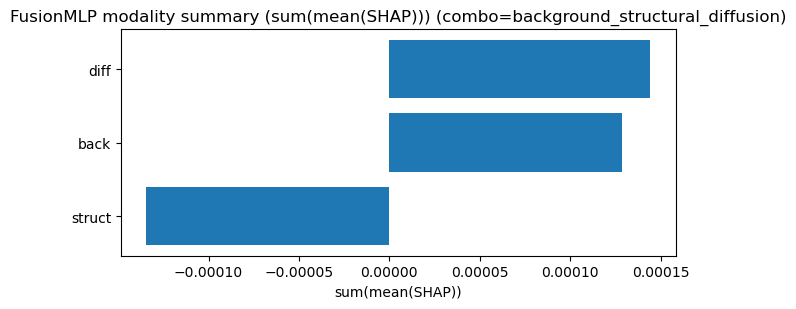

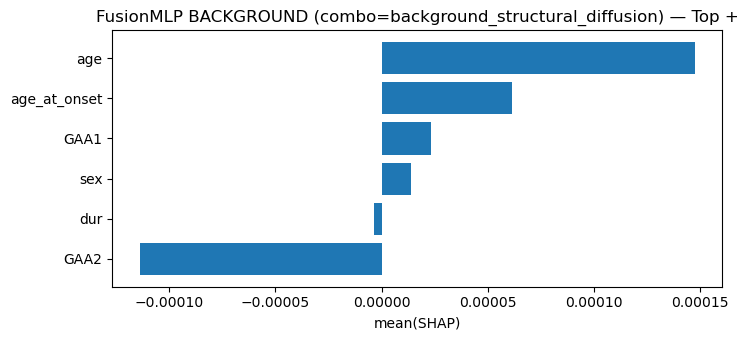

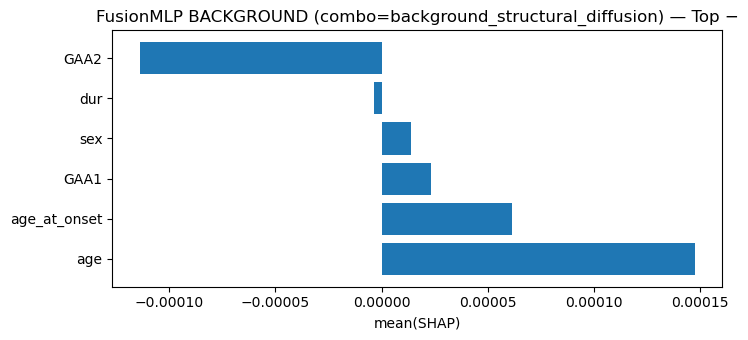

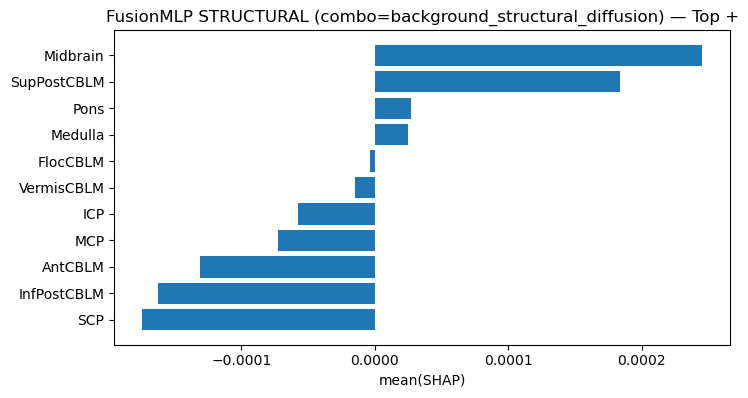

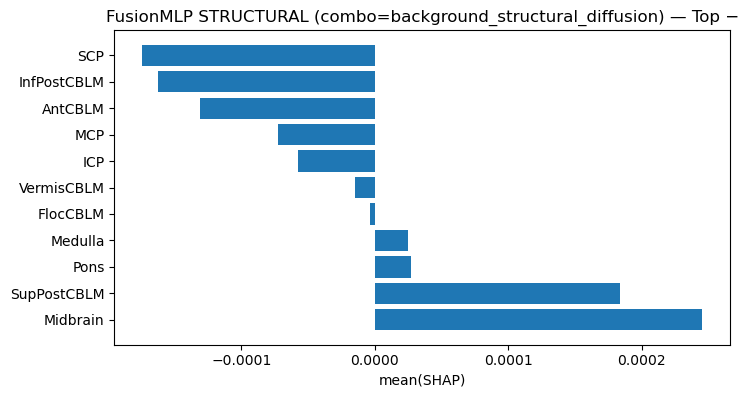

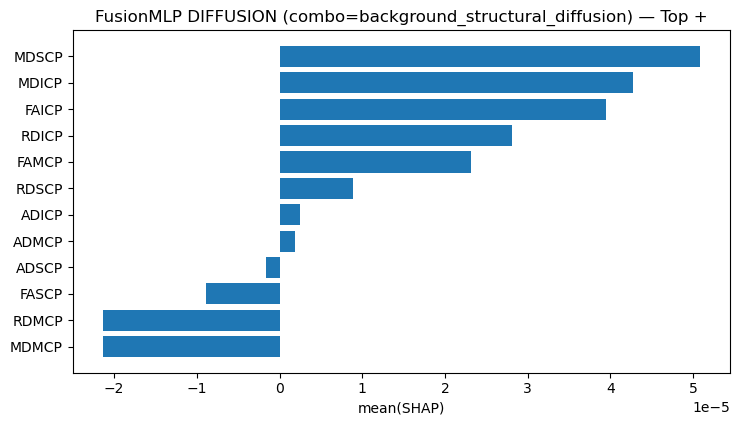

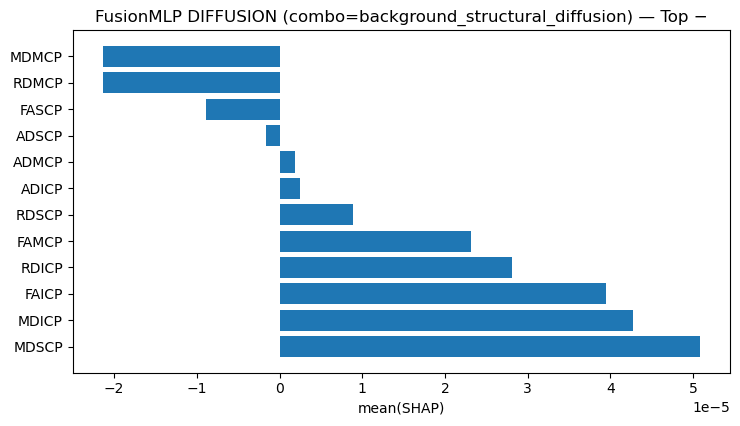

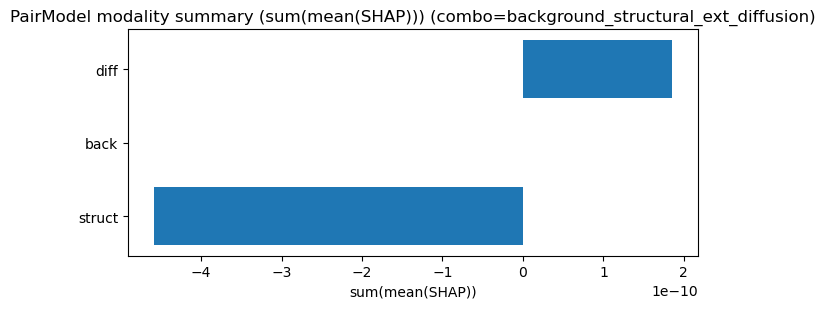

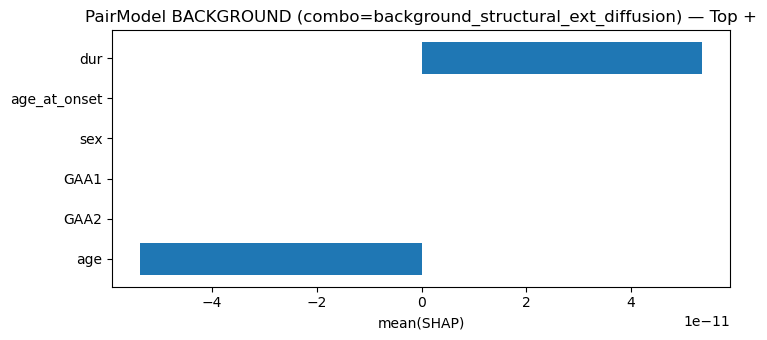

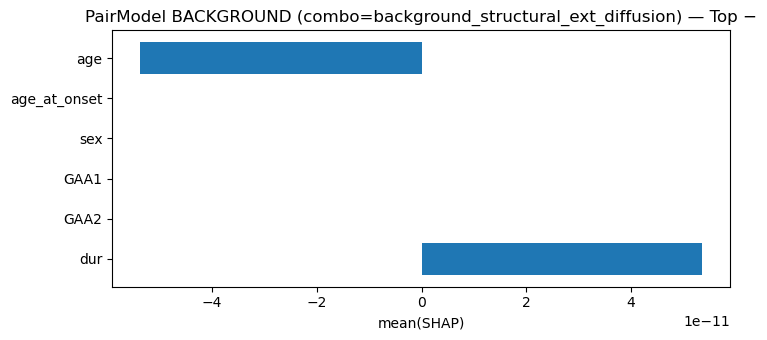

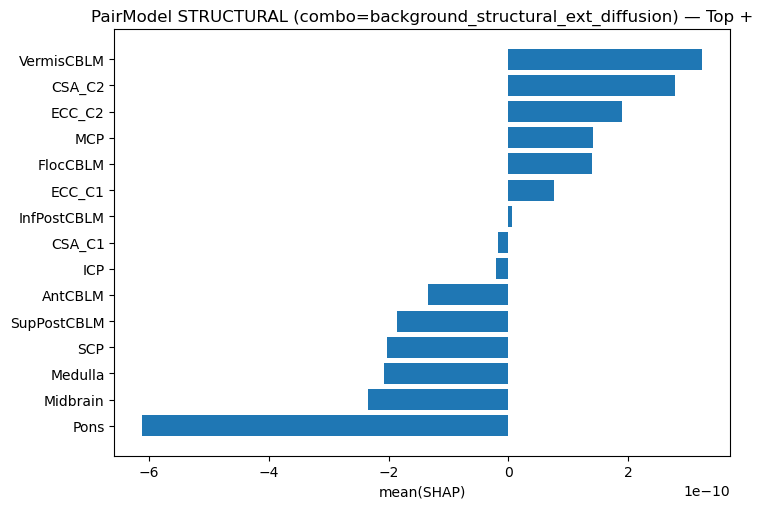

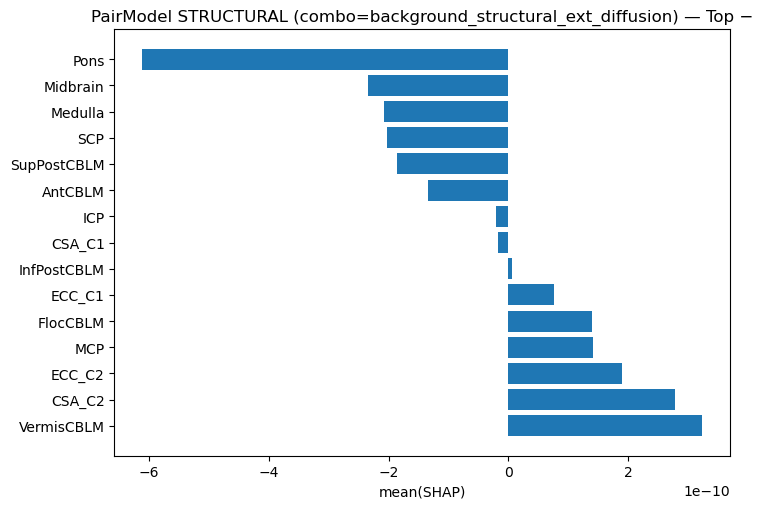

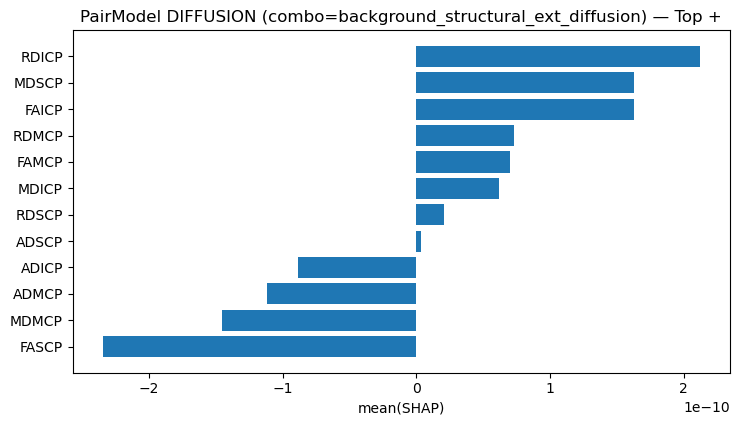

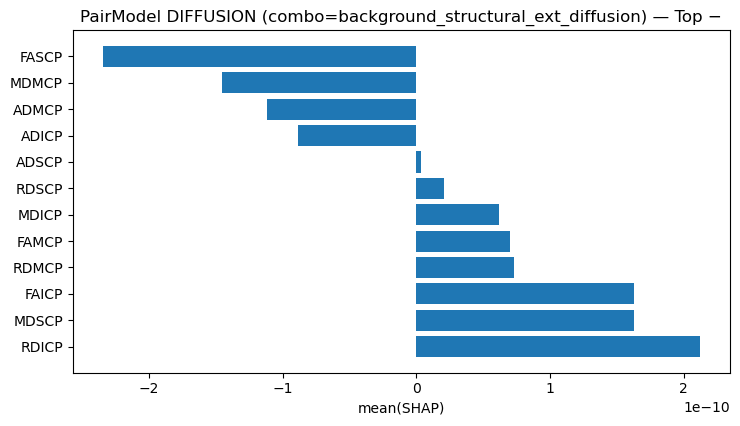

In [13]:
# Purpose: SHAP (Shapley) feature importance for FusionMLP and PairModel

try:
    import shap
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "SHAP is not installed in the current notebook kernel. Run: %pip install shap"
    ) from e

import matplotlib.pyplot as plt

SHAP_BACKGROUND_SIZE = 40
SHAP_EVAL_SIZE = 120
TOP_N_FEATURES = 15

# DeepExplainer additivity checks can fail for some graphs/ops; disable by default
SHAP_CHECK_ADDITIVITY = False

rng = np.random.RandomState(RANDOM_SEED)


def _as_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _squeeze_last_if_unit(arr):
    arr = np.asarray(arr)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        return arr[..., 0]
    if arr.ndim == 2 and arr.shape[-1] == 1:
        return arr[:, 0]
    return arr


def _mean_shap_per_feature(shap_arr):
    v = _squeeze_last_if_unit(_as_numpy(shap_arr))
    if v.ndim != 2:
        raise ValueError(
            f"Expected SHAP values with shape (n_samples, n_features) or (n_samples, n_features, 1), got {v.shape}"
        )
    return v.mean(axis=0)


def _normalize_deep_shap_values(shap_values):
    # DeepExplainer can return:
    # - list[input] (single output)
    # - list[output][input] (multi-output)
    if isinstance(shap_values, list) and len(shap_values) > 0 and isinstance(shap_values[0], list):
        shap_values = shap_values[0]
    return shap_values


def _shap_values_safe(explainer, inputs):
    """Call explainer.shap_values with additivity check control (SHAP version compatible)."""
    try:
        return explainer.shap_values(inputs, check_additivity=SHAP_CHECK_ADDITIVITY)
    except TypeError:
        # older SHAP may not accept check_additivity kw
        return explainer.shap_values(inputs)


def _plot_top_pos_neg(mean_shap_1d, feature_names, title, top_n=TOP_N_FEATURES):
    if len(feature_names) == 0:
        print(f"[skip] {title} (no features)")
        return

    vals = np.asarray(mean_shap_1d).reshape(-1)
    if len(vals) != len(feature_names):
        raise ValueError(
            f"Length mismatch for {title}: got {len(vals)} values vs {len(feature_names)} feature names. "
            "This usually means SHAP returned an unexpected tensor shape."
        )

    s = pd.Series(vals, index=feature_names)

    # Top positive
    s_pos = s.sort_values(ascending=False).head(top_n)
    if len(s_pos) > 0:
        s_pos = s_pos.iloc[::-1]
        h = max(3.5, 0.28 * len(s_pos) + 1.0)
        plt.figure(figsize=(7.5, h))
        plt.barh(s_pos.index, s_pos.values)
        plt.title(f"{title} — Top +")
        plt.xlabel('mean(SHAP)')
        plt.tight_layout()
        plt.show()

    # Top negative
    s_neg = s.sort_values(ascending=True).head(top_n)
    if len(s_neg) > 0:
        s_neg = s_neg.iloc[::-1]
        h = max(3.5, 0.28 * len(s_neg) + 1.0)
        plt.figure(figsize=(7.5, h))
        plt.barh(s_neg.index, s_neg.values)
        plt.title(f"{title} — Top −")
        plt.xlabel('mean(SHAP)')
        plt.tight_layout()
        plt.show()


def _plot_modality_summary(modality_to_value, title):
    s = pd.Series(modality_to_value).sort_values(ascending=True)
    plt.figure(figsize=(6.5, 3.2))
    plt.barh(s.index, s.values)
    plt.title(title)
    plt.xlabel('sum(mean(SHAP))')
    plt.tight_layout()
    plt.show()


def _sample_idx(n, k):
    k = min(int(k), int(n))
    if k <= 0:
        return np.array([], dtype=int)
    if k == n:
        return np.arange(n)
    return rng.choice(np.arange(n), size=k, replace=False)


def _has_all_modalities(meta):
    return (
        len(meta.get('back_idx', [])) > 0
        and len(meta.get('struct_idx', [])) > 0
        and len(meta.get('diff_idx', [])) > 0
    )


def _pick_best_combo(results_df, prefer_all_modalities=True):
    df = results_df.sort_values('d', ascending=False).copy()
    if prefer_all_modalities:
        df_full = df[df['combination'].map(lambda name: _has_all_modalities(combo_meta[name]))]
        if len(df_full) > 0:
            return df_full.iloc[0]['combination'], True
    return df.iloc[0]['combination'], False


class _FusionProgWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x_struct, x_diff, x_back):
        return self.model(x_struct, x_diff, x_back)[2]


class _PairProgWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x1, x2):
        return self.model(x1, x2)[0]


def _train_fusion_for_combo(combo_name):
    combo = next(c for c in combinations if c['name'] == combo_name)
    feats = combo['features']
    meta = combo_meta[combo_name]
    sub = filter_complete_pairs(long_df, subject_col, feats)

    scaler = StandardScaler().fit(sub[feats].values)
    model, _ = train_fusion_model(sub, feats, meta, scaler)
    model.eval()

    arrays = prepare_fusion_arrays(sub, feats, meta, scaler)
    return model, arrays, feats, meta, sub


def _build_pair_tensors(sub_df, feats, scaler):
    x1_list, x2_list, sid_list = [], [], []
    for sid, g in sub_df.groupby(subject_col):
        g = g.sort_values('visit')
        if g['visit'].nunique() != 2:
            continue
        x1 = scaler.transform(g[g['visit'] == 1][feats].values)
        x2 = scaler.transform(g[g['visit'] == 2][feats].values)
        if x1.shape[0] != 1 or x2.shape[0] != 1:
            continue
        x1_list.append(x1[0])
        x2_list.append(x2[0])
        sid_list.append(sid)

    X1 = np.asarray(x1_list, dtype=np.float32)
    X2 = np.asarray(x2_list, dtype=np.float32)
    return (
        torch.tensor(X1, dtype=torch.float32, device=DEVICE),
        torch.tensor(X2, dtype=torch.float32, device=DEVICE),
        np.asarray(sid_list),
    )


def _train_pair_for_combo(combo_name):
    combo = next(c for c in combinations if c['name'] == combo_name)
    feats = combo['features']
    sub = filter_complete_pairs(long_df, subject_col, feats)

    scaler = StandardScaler().fit(sub[feats].values)
    model, _ = train_pair_model(sub, feats, scaler)
    model.eval()

    x1, x2, sids = _build_pair_tensors(sub, feats, scaler)
    return model, (x1, x2), feats, combo_meta[combo_name], sub, sids


# pick best combinations from the earlier sweep (prefer combos with all modalities)
best_fusion_combo, fusion_full = _pick_best_combo(fusion_results_df, prefer_all_modalities=True)
best_pair_combo, pair_full = _pick_best_combo(pair_results_df, prefer_all_modalities=True)
print('Best fusion combo:', best_fusion_combo, '(all modalities)' if fusion_full else '(fallback)')
print('Best pair combo:', best_pair_combo, '(all modalities)' if pair_full else '(fallback)')


# ---- FusionMLP SHAP (progression head) ----
fusion_model, fusion_arrays, fusion_feats, fusion_meta, fusion_sub = _train_fusion_for_combo(best_fusion_combo)
fusion_wrapper = _FusionProgWrapper(fusion_model)

n_rows = fusion_arrays['struct'].shape[0]
idx_bg = _sample_idx(n_rows, SHAP_BACKGROUND_SIZE)
idx_ev = _sample_idx(n_rows, SHAP_EVAL_SIZE)

bg_inputs = [fusion_arrays['struct'][idx_bg], fusion_arrays['diff'][idx_bg], fusion_arrays['back'][idx_bg]]
ev_inputs = [fusion_arrays['struct'][idx_ev], fusion_arrays['diff'][idx_ev], fusion_arrays['back'][idx_ev]]

fusion_explainer = shap.DeepExplainer(fusion_wrapper, bg_inputs)
fusion_shap = _normalize_deep_shap_values(_shap_values_safe(fusion_explainer, ev_inputs))

fusion_struct_names = [fusion_feats[i] for i in fusion_meta['struct_idx']]
fusion_diff_names = [fusion_feats[i] for i in fusion_meta['diff_idx']]
fusion_back_names = [fusion_feats[i] for i in fusion_meta['back_idx']]

fusion_struct_mean = _mean_shap_per_feature(fusion_shap[0]) if len(fusion_struct_names) else np.array([])
fusion_diff_mean = _mean_shap_per_feature(fusion_shap[1]) if len(fusion_diff_names) else np.array([])
fusion_back_mean = _mean_shap_per_feature(fusion_shap[2]) if len(fusion_back_names) else np.array([])

_plot_modality_summary(
    {
        'struct': float(fusion_struct_mean.sum()) if fusion_struct_mean.size else 0.0,
        'diff': float(fusion_diff_mean.sum()) if fusion_diff_mean.size else 0.0,
        'back': float(fusion_back_mean.sum()) if fusion_back_mean.size else 0.0,
    },
    title=f'FusionMLP modality summary (sum(mean(SHAP))) (combo={best_fusion_combo})',
)

_plot_top_pos_neg(fusion_back_mean, fusion_back_names, f'FusionMLP BACKGROUND (combo={best_fusion_combo})')
_plot_top_pos_neg(fusion_struct_mean, fusion_struct_names, f'FusionMLP STRUCTURAL (combo={best_fusion_combo})')
_plot_top_pos_neg(fusion_diff_mean, fusion_diff_names, f'FusionMLP DIFFUSION (combo={best_fusion_combo})')


# ---- PairModel SHAP (progression head) ----
pair_model, (pair_x1, pair_x2), pair_feats, pair_meta, pair_sub, pair_sids = _train_pair_for_combo(best_pair_combo)
pair_wrapper = _PairProgWrapper(pair_model)

n_pairs = pair_x1.shape[0]
idx_bg = _sample_idx(n_pairs, SHAP_BACKGROUND_SIZE)
idx_ev = _sample_idx(n_pairs, SHAP_EVAL_SIZE)

bg_inputs = [pair_x1[idx_bg], pair_x2[idx_bg]]
ev_inputs = [pair_x1[idx_ev], pair_x2[idx_ev]]

pair_explainer = shap.DeepExplainer(pair_wrapper, bg_inputs)
pair_shap = _normalize_deep_shap_values(_shap_values_safe(pair_explainer, ev_inputs))

pair_mean_x1 = _mean_shap_per_feature(pair_shap[0])
pair_mean_x2 = _mean_shap_per_feature(pair_shap[1])

# signed net contribution across both visits
pair_feat_mean = pair_mean_x1 + pair_mean_x2

# modality indices follow `pair_feats` ordering
back_idx = np.array(pair_meta['back_idx'], dtype=int)
struct_idx = np.array(pair_meta['struct_idx'], dtype=int)
diff_idx = np.array(pair_meta['diff_idx'], dtype=int)

_plot_modality_summary(
    {
        'struct': float(pair_feat_mean[struct_idx].sum()) if struct_idx.size else 0.0,
        'diff': float(pair_feat_mean[diff_idx].sum()) if diff_idx.size else 0.0,
        'back': float(pair_feat_mean[back_idx].sum()) if back_idx.size else 0.0,
    },
    title=f'PairModel modality summary (sum(mean(SHAP))) (combo={best_pair_combo})',
)

if back_idx.size:
    _plot_top_pos_neg(pair_feat_mean[back_idx], [pair_feats[i] for i in back_idx], f'PairModel BACKGROUND (combo={best_pair_combo})')
else:
    print('[skip] PairModel BACKGROUND (no features)')

if struct_idx.size:
    _plot_top_pos_neg(pair_feat_mean[struct_idx], [pair_feats[i] for i in struct_idx], f'PairModel STRUCTURAL (combo={best_pair_combo})')
else:
    print('[skip] PairModel STRUCTURAL (no features)')

if diff_idx.size:
    _plot_top_pos_neg(pair_feat_mean[diff_idx], [pair_feats[i] for i in diff_idx], f'PairModel DIFFUSION (combo={best_pair_combo})')
else:
    print('[skip] PairModel DIFFUSION (no features)')
